In [1]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

#### **Creating the Agent**
- We added the `say_wealth()` (perviously `say_hi()`) function to indicate the action that the agents do for every time step/tick.

In [2]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # pass the parameters to the parent class
        super().__init__(model)

        # create the agent's variables and set the initial values.
        self.wealth = 1

    def exchange(self):
        # The agent's step will go here.
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            if other_agent is not None:
                other_agent.wealth += 1
                self.wealth =+ 1

#### **Creating the Model**
- the Model serves as the "field" where the agents are placed. Imagine it as a grid.
- the `step()` function calls `mesa.Agent.shuffle_do()`, which takes the action function (`say_hi` > `say_wealth`) of the agent as a parameter. The Model class must contain the `step()` function.

In [17]:
class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, seed=None):
        super().__init__(seed=seed)
        self.num_agents = n

        # create agents
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        """Advance the model by one step."""
        self.agents.shuffle_do("exchange")

#### Learnings #1:
1. `self.Agent.do` and `self.Agent.shuffle_do` differ in the order of execution. Meaning, the models are created sequentially in `do`, while is it shuffled in `shuffle_do`.
2. The `seed` parameter doesn't affect the `do()` function. It only affects `shuffle_do()`.

#### **Running the Model**

In [11]:
starter_model = MoneyModel(10)
for _ in range(30):
    starter_model.step()

#### **Getting Data from the Model**

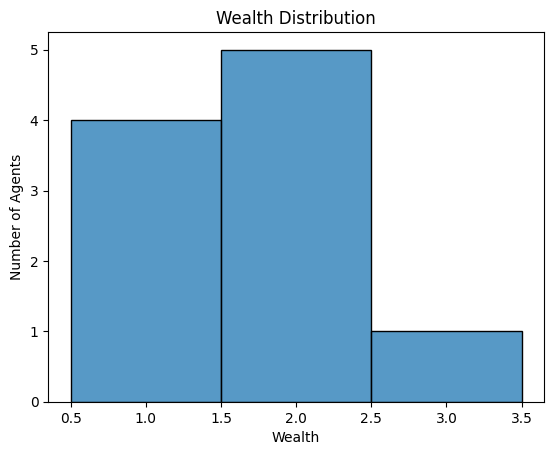

In [ ]:
agent_wealth = [agent.wealth for agent in starter_model.agents]         # use list comprehension to access the wealth of each agent in the model

g = sns.histplot(agent_wealth, discrete=True) 
g.set(
    title="Wealth Distribution",
    xlabel="Wealth",
    ylabel="Number of Agents"
); # Semicolon suppresses the output of the last last line of the cell

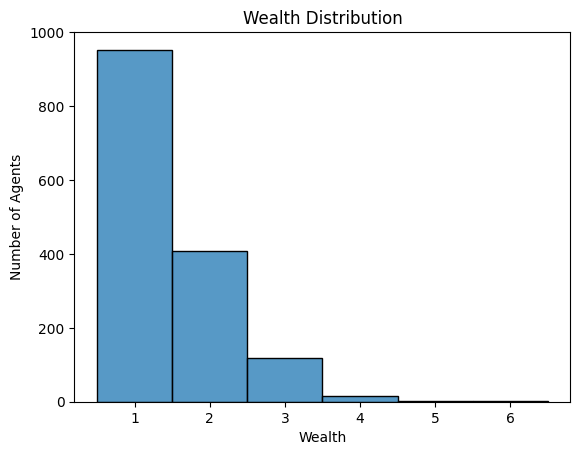

In [25]:
all_wealth = []

for _ in range(100):
    model = MoneyModel(15)
    for _ in range(100):
        model.step()
    
    for agent in model.agents:
        all_wealth.append(agent.wealth)

# Use Seaborn
g = sns. histplot(all_wealth, discrete=True)
g.set(
    title="Wealth Distribution",
    xlabel="Wealth",
    ylabel="Number of Agents"
);

#### Learnings #2:
1. To access the data from the model, iterate through the `agents` variable of the model object using a list comprehension. (model.agents)

### Next: AgentSet
- https://mesa.readthedocs.io/stable/tutorials/1_agentset.html